In [1]:
!pip install -q kaggle librosa

In [2]:
import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle authentication configured.")

TimeoutException: Requesting secret KAGGLE_API_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.

In [1]:
import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle authentication configured.")

Kaggle authentication configured.


In [2]:
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:02<00:00, 185MB/s]



In [3]:
!unzip -q -o ravdess-emotional-speech-audio.zip -d ravdess_data

In [4]:
import os

for root, dirs, files in os.walk("ravdess_data"):
    print(root, "->", len(files), "files")
    if files:
        print("Example:", files[:3])

ravdess_data -> 0 files
ravdess_data/Actor_11 -> 60 files
Example: ['03-01-02-01-01-01-11.wav', '03-01-05-02-01-02-11.wav', '03-01-08-01-01-01-11.wav']
ravdess_data/Actor_18 -> 60 files
Example: ['03-01-08-01-01-02-18.wav', '03-01-02-01-01-01-18.wav', '03-01-04-01-01-02-18.wav']
ravdess_data/Actor_16 -> 60 files
Example: ['03-01-06-02-02-02-16.wav', '03-01-02-01-01-02-16.wav', '03-01-02-02-01-01-16.wav']
ravdess_data/Actor_13 -> 60 files
Example: ['03-01-03-02-02-01-13.wav', '03-01-03-02-01-02-13.wav', '03-01-07-02-02-01-13.wav']
ravdess_data/audio_speech_actors_01-24 -> 0 files
ravdess_data/audio_speech_actors_01-24/Actor_11 -> 60 files
Example: ['03-01-02-01-01-01-11.wav', '03-01-05-02-01-02-11.wav', '03-01-08-01-01-01-11.wav']
ravdess_data/audio_speech_actors_01-24/Actor_18 -> 60 files
Example: ['03-01-08-01-01-02-18.wav', '03-01-02-01-01-01-18.wav', '03-01-04-01-01-02-18.wav']
ravdess_data/audio_speech_actors_01-24/Actor_16 -> 60 files
Example: ['03-01-06-02-02-02-16.wav', '03-01-0

In [5]:
import os
import glob
import pandas as pd

# Use only one copy of the dataset
data_path = "ravdess_data/audio_speech_actors_01-24"

# RAVDESS emotion codes
emotion_map = {
    1: "neutral",
    2: "calm",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "fearful",
    7: "disgust",
    8: "surprised"
}

audio_files = glob.glob(
    os.path.join(data_path, "Actor_*", "*.wav")
)

data = []

for file_path in audio_files:
    filename = os.path.basename(file_path)
    parts = filename.replace(".wav", "").split("-")

    emotion_code = int(parts[2])

    data.append({
        "file_path": file_path,
        "emotion_code": emotion_code,
        "emotion": emotion_map[emotion_code]
    })

df = pd.DataFrame(data)

print("Total audio files:", len(df))
print("\nEmotion distribution:")
print(df["emotion"].value_counts().sort_index())

Total audio files: 1440

Emotion distribution:
emotion
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral       96
sad          192
surprised    192
Name: count, dtype: int64


In [6]:
import numpy as np
import librosa
from tqdm import tqdm

# MFCC settings
SAMPLE_RATE = 22050
N_MFCC = 40
MAX_PAD_LEN = 174

def extract_mfcc(file_path):
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=N_MFCC
    )

    # Make every MFCC have the same number of time frames
    if mfcc.shape[1] < MAX_PAD_LEN:
        pad_width = MAX_PAD_LEN - mfcc.shape[1]
        mfcc = np.pad(
            mfcc,
            pad_width=((0, 0), (0, pad_width)),
            mode="constant"
        )
    else:
        mfcc = mfcc[:, :MAX_PAD_LEN]

    return mfcc


X = []
y = []

print("Extracting MFCC features...")

for _, row in tqdm(df.iterrows(), total=len(df)):
    mfcc = extract_mfcc(row["file_path"])
    X.append(mfcc)
    y.append(row["emotion"])

X = np.array(X)
y = np.array(y)

print("\nMFCC extraction completed.")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("MFCC minimum:", X.min())
print("MFCC maximum:", X.max())

Extracting MFCC features...


100%|██████████| 1440/1440 [00:48<00:00, 29.48it/s]



MFCC extraction completed.
X shape: (1440, 40, 174)
y shape: (1440,)
MFCC minimum: -1087.2701
MFCC maximum: 238.0774


In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Convert emotion names into numeric labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Emotion classes:")
print(label_encoder.classes_)

# Add channel dimension for CNN
X_cnn = X[..., np.newaxis]

print("\nCNN input shape:", X_cnn.shape)
print("Labels shape:", y_encoded.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Emotion classes:
['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']

CNN input shape: (1440, 40, 174, 1)
Labels shape: (1440,)

Training data: (1152, 40, 174, 1)
Testing data: (288, 40, 174, 1)
Training labels: (1152,)
Testing labels: (288,)


In [8]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

cnn_model = Sequential([
    Input(shape=(40, 174, 1)),

    Conv2D(32, kernel_size=(3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(8, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 172, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 84, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,752,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,772,872 (10.58 MB)

 Trainable params: 2,772,680 (10.58 MB)

 Non-trainable params: 192 (768.00 B)

In [9]:
history = cnn_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 437ms/step - accuracy: 0.1461 - loss: 3.9818 - val_accuracy: 0.1445 - val_loss: 2.0409
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 445ms/step - accuracy: 0.1481 - loss: 2.0519 - val_accuracy: 0.1040 - val_loss: 2.0721
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 422ms/step - accuracy: 0.1532 - loss: 2.0371 - val_accuracy: 0.1040 - val_loss: 2.0473
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 432ms/step - accuracy: 0.1563 - loss: 2.0457 - val_accuracy: 0.1734 - val_loss: 2.0400
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 436ms/step - accuracy: 0.1502 - loss: 2.0583 - val_accuracy: 0.1561 - val_loss: 2.0483
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 437ms/step - accuracy: 0.1614 - loss: 2.0306 - val_accuracy: 0.1272 - val_loss: 2.0387
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 438ms/step - accuracy: 0.1655 - loss: 2.0159 - val_accuracy: 0.1214 - val_loss: 2.0169
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 445ms/step - accuracy: 0.1399 - loss: 2.0437 - val_accu

In [10]:
# Normalize MFCC features using training-set statistics

mean = X_train.mean()
std = X_train.std()

X_train_norm = (X_train - mean) / (std + 1e-8)
X_test_norm = (X_test - mean) / (std + 1e-8)

print("Training mean after normalization:", X_train_norm.mean())
print("Training std after normalization:", X_train_norm.std())
print("Training shape:", X_train_norm.shape)
print("Testing shape:", X_test_norm.shape)

Training mean after normalization: 1.8216337e-08
Training std after normalization: 1.0000004
Training shape: (1152, 40, 174, 1)
Testing shape: (288, 40, 174, 1)


In [11]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

# Rebuild CNN from scratch
cnn_model = Sequential([
    Input(shape=(40, 174, 1)),

    Conv2D(32, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(8, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train using normalized MFCC features
history = cnn_model.fit(
    X_train_norm,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 16s 418ms/step - accuracy: 0.1553 - loss: 4.9289 - val_accuracy: 0.1965 - val_loss: 2.0457
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 428ms/step - accuracy: 0.1910 - loss: 2.0086 - val_accuracy: 0.1445 - val_loss: 2.1685
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 415ms/step - accuracy: 0.1583 - loss: 2.0640 - val_accuracy: 0.1618 - val_loss: 2.5737
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 417ms/step - accuracy: 0.1563 - loss: 2.0562 - val_accuracy: 0.1618 - val_loss: 3.0354
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 423ms/step - accuracy: 0.1593 - loss: 2.0490 - val_accuracy: 0.1618 - val_loss: 3.3708
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 425ms/step - accuracy: 0.1553 - loss: 2.0387 - val_accuracy: 0.1618 - val_loss: 3.5925
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 452ms/step - accuracy: 0.1655 - loss: 2.0383 - val_accuracy: 0.1561 - val_loss: 3.5201
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 469ms/step - accuracy: 0.1604 - loss: 2.0281 - val_accu

In [12]:
# Convert MFCC data from:
# (samples, MFCC coefficients, time frames, channel)
# to:
# (samples, time frames, MFCC coefficients)

X_train_1d = X_train_norm.squeeze(-1).transpose(0, 2, 1)
X_test_1d = X_test_norm.squeeze(-1).transpose(0, 2, 1)

print("1D CNN training shape:", X_train_1d.shape)
print("1D CNN testing shape:", X_test_1d.shape)

1D CNN training shape: (1152, 174, 40)
1D CNN testing shape: (288, 174, 40)


In [13]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    GlobalAveragePooling1D,
    Dense
)

cnn_1d = Sequential([
    Input(shape=(174, 40)),

    Conv1D(64, kernel_size=5, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    Conv1D(128, kernel_size=5, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    Conv1D(256, kernel_size=3, activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    GlobalAveragePooling1D(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(8, activation="softmax")
])

cnn_1d.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_1d.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 174, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 174, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 87, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 87, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 87, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 87, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 43, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 43, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,232 (735.28 KB)

 Trainable params: 187,336 (731.78 KB)

 Non-trainable params: 896 (3.50 KB)

In [14]:
history_1d = cnn_1d.fit(
    X_train_1d,
    y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.2666 - loss: 1.8984 - val_accuracy: 0.1040 - val_loss: 2.2506
Epoch 2/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.3994 - loss: 1.6226 - val_accuracy: 0.1098 - val_loss: 2.3487
Epoch 3/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.4637 - loss: 1.4821 - val_accuracy: 0.1214 - val_loss: 2.3991
Epoch 4/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.4831 - loss: 1.4127 - val_accuracy: 0.1850 - val_loss: 2.3677
Epoch 5/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.5179 - loss: 1.3225 - val_accuracy: 0.1850 - val_loss: 2.6745
Epoch 6/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.5720 - loss: 1.2115 - val_accuracy: 0.2139 - val_loss: 3.0965
Epoch 7/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.5761 - loss: 1.1271 - val_accuracy: 0.2370 - val_loss: 3.7627
Epoch 8/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.5904 - loss: 1.1170 - val_accuracy: 0.2428 - v

In [15]:
# Evaluate the trained model on the unseen test set

test_loss, test_accuracy = cnn_1d.evaluate(
    X_test_1d,
    y_test,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6493 - loss: 1.2522

Test Loss: 1.2522274255752563
Test Accuracy: 0.6493055820465088
Test Accuracy: 64.93%


Classification Report:

              precision    recall  f1-score   support

       angry       1.00      0.68      0.81        38
        calm       0.74      0.68      0.71        38
     disgust       0.95      0.47      0.63        38
     fearful       0.49      0.95      0.64        39
       happy       0.61      0.85      0.71        39
     neutral       0.67      0.11      0.18        19
         sad       0.46      0.63      0.53        38
   surprised       0.91      0.54      0.68        39

    accuracy                           0.65       288
   macro avg       0.73      0.61      0.61       288
weighted avg       0.73      0.65      0.64       288



<Figure size 900x800 with 0 Axes>

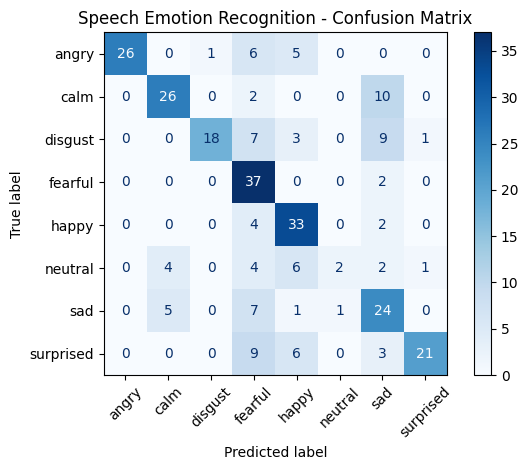

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Predictions
y_pred_prob = cnn_1d.predict(X_test_1d, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Classification report
print("Classification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Speech Emotion Recognition - Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

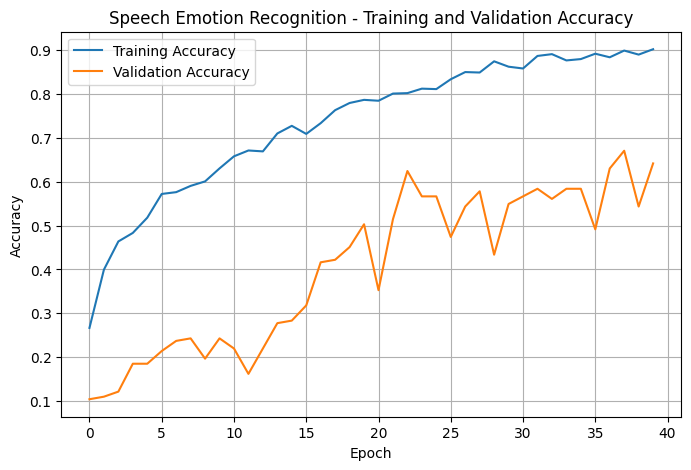

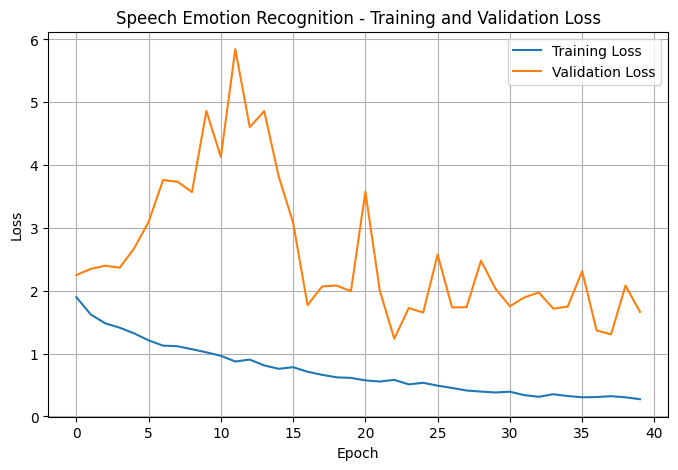

In [17]:
import matplotlib.pyplot as plt

# Training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history_1d.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_1d.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Speech Emotion Recognition - Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    "training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    history_1d.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_1d.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Speech Emotion Recognition - Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    "training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# Save the final trained Speech Emotion Recognition model

model_path = "speech_emotion_cnn.keras"

cnn_1d.save(model_path)

print("Model saved successfully:")
print(model_path)

Model saved successfully:
speech_emotion_cnn.keras


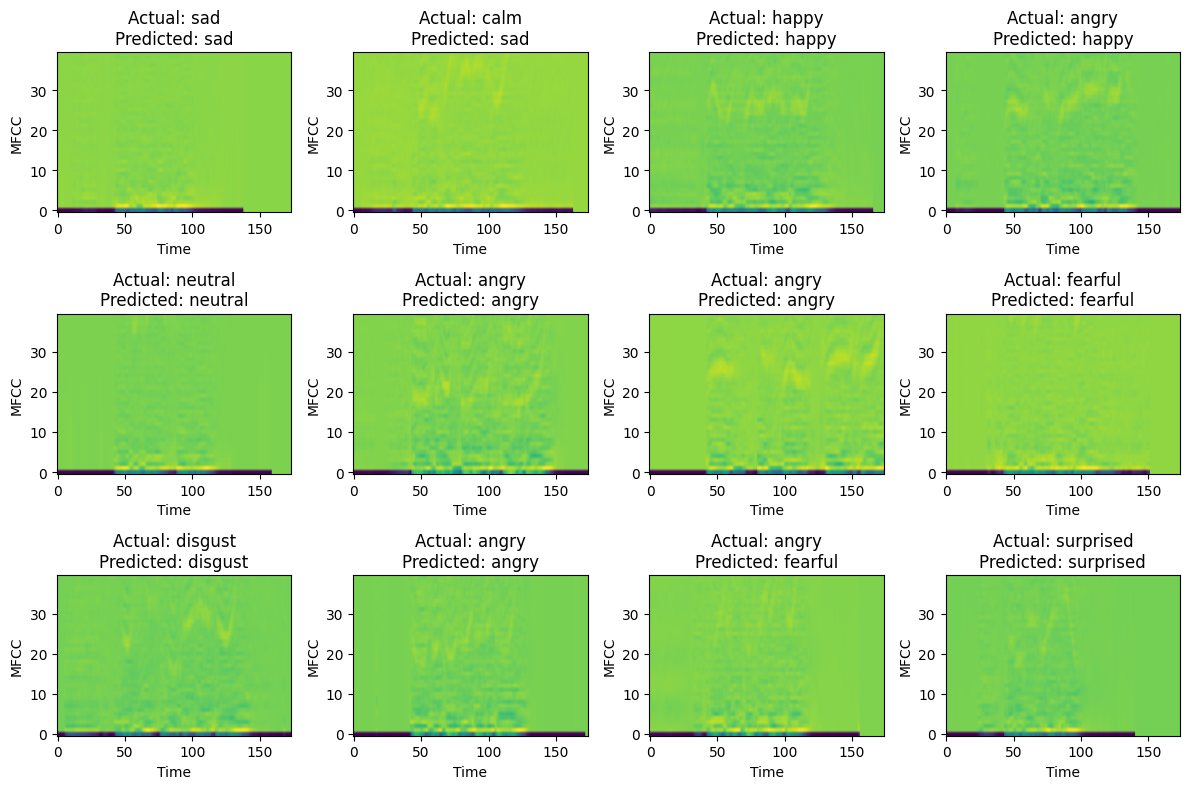

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Select 12 test samples
sample_indices = np.arange(12)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(sample_indices):
    plt.subplot(3, 4, i + 1)

    # MFCC visualization
    plt.imshow(
        X_test_1d[idx].T,
        aspect="auto",
        origin="lower",
        cmap="viridis"
    )

    actual_emotion = label_encoder.classes_[y_test[idx]]
    predicted_emotion = label_encoder.classes_[y_pred[idx]]

    plt.title(
        f"Actual: {actual_emotion}\nPredicted: {predicted_emotion}"
    )

    plt.xlabel("Time")
    plt.ylabel("MFCC")

plt.tight_layout()

plt.savefig(
    "sample_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()